<a href="https://colab.research.google.com/github/sanjeetsheoran/LearningGit/blob/main/unsuperpractical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


For clustering, we'll use 'Annual Income (k$)' and 'Spending Score (1-100)' as our features. We'll also preprocess them using `StandardScaler`.

In [3]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data (first 5 rows):")
display(X_scaled[:5])

Scaled data (first 5 rows):


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

Now, let's implement K-Means from scratch. We'll define the following functions:

1.  `initialize_centroids(data, k)`: Randomly selects `k` data points as initial centroids.
2.  `assign_clusters(data, centroids)`: Assigns each data point to the closest centroid.
3.  `update_centroids(data, assignments, k)`: Recalculates the centroids based on the mean of the assigned data points.
4.  `calculate_inertia(data, centroids, assignments)`: Calculates the within-cluster sum of squares (inertia).
5.  `kmeans(data, k, max_iterations=100)`: The main K-Means algorithm that iteratively performs assignment and update steps.

In [4]:
def initialize_centroids(data, k):
    # Randomly select k data points as initial centroids
    indices = np.random.choice(data.shape[0], k, replace=False)
    return data[indices]

def assign_clusters(data, centroids):
    assignments = []
    for point in data:
        distances = np.linalg.norm(point - centroids, axis=1)
        assignments.append(np.argmin(distances))
    return np.array(assignments)

def update_centroids(data, assignments, k):
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        # Get all points assigned to cluster i
        cluster_points = data[assignments == i]
        if len(cluster_points) > 0:
            new_centroids[i] = np.mean(cluster_points, axis=0)
    return new_centroids

def calculate_inertia(data, centroids, assignments):
    inertia = 0
    for i, centroid in enumerate(centroids):
        cluster_points = data[assignments == i]
        inertia += np.sum((cluster_points - centroid)**2)
    return inertia

def kmeans(data, k, max_iterations=100, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    # 1. Initialize centroids
    centroids = initialize_centroids(data, k)

    for iteration in range(max_iterations):
        # 2. Assign clusters
        assignments = assign_clusters(data, centroids)

        # 3. Update centroids
        new_centroids = update_centroids(data, assignments, k)

        # Check for convergence
        if np.allclose(centroids, new_centroids):
            print(f"K-Means converged at iteration {iteration + 1}")
            break

        centroids = new_centroids
    else:
        print(f"K-Means did not converge after {max_iterations} iterations")

    inertia = calculate_inertia(data, centroids, assignments)
    return assignments, centroids, inertia

Now, let's run our custom K-Means algorithm with `k=5` clusters and a `random_state` for reproducibility. Then, we will visualize the clusters.

In [5]:
# Run custom K-Means
k_optimal = 5 # Starting with 5 clusters
assignments_custom, centroids_custom, inertia_custom = kmeans(X_scaled, k=k_optimal, random_state=42)

print(f"Custom K-Means Inertia for k={k_optimal}: {inertia_custom:.2f}")

K-Means converged at iteration 11
Custom K-Means Inertia for k=5: 65.58


Let's visualize the clusters formed by our custom K-Means implementation.

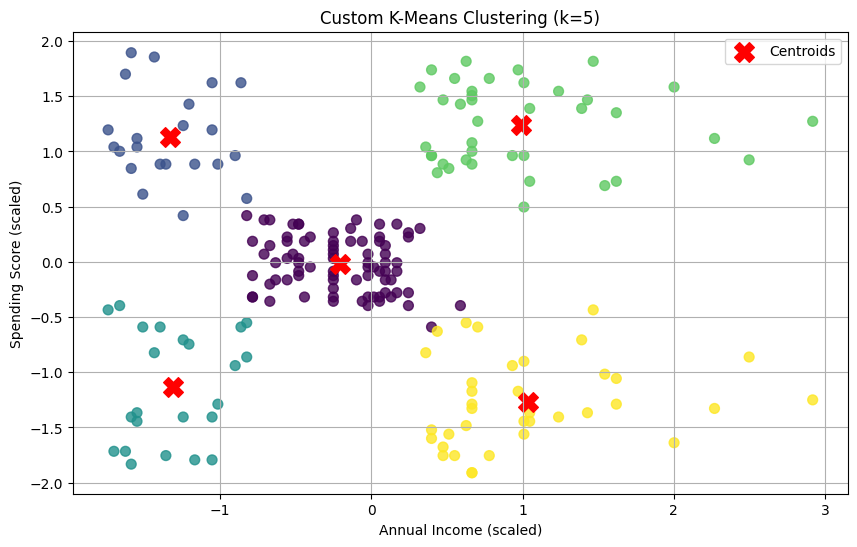

In [6]:
# Visualize the custom K-Means clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=assignments_custom, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids_custom[:, 0], centroids_custom[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'Custom K-Means Clustering (k={k_optimal})')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.grid(True)
plt.show()

To find the optimal number of clusters, we will use the **Elbow Method**. We'll run our custom K-Means for a range of `k` values and plot the inertia for each `k`.

K-Means converged at iteration 2
K-Means converged at iteration 9
K-Means converged at iteration 15
K-Means converged at iteration 7
K-Means converged at iteration 11
K-Means converged at iteration 5
K-Means converged at iteration 10
K-Means converged at iteration 8
K-Means converged at iteration 12
K-Means converged at iteration 11


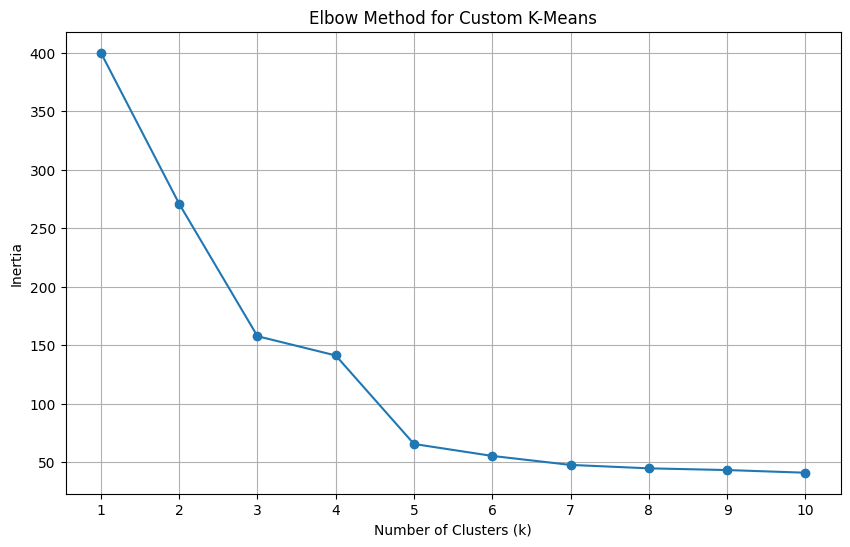

In [16]:
# Elbow Method for custom K-Means
inertias = []
silhouette_scores = [] # New list to store silhouette scores
k_range = range(1, 11) # Test k from 1 to 10

for k in k_range:
    if k == 1: # Silhouette score is not defined for k=1
        assignments, _, current_inertia = kmeans(X_scaled, k=k, random_state=42)
        inertias.append(current_inertia)
        silhouette_scores.append(np.nan) # Append NaN for k=1
    else:
        assignments, _, current_inertia = kmeans(X_scaled, k=k, random_state=42)
        inertias.append(current_inertia)
        current_silhouette_score = silhouette_score(X_scaled, assignments)
        silhouette_scores.append(current_silhouette_score)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Custom K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

### Silhouette Score for Different k Values

To complement the Elbow Method, we can also plot the Silhouette Scores for each `k`. A higher Silhouette Score indicates better-defined clusters.

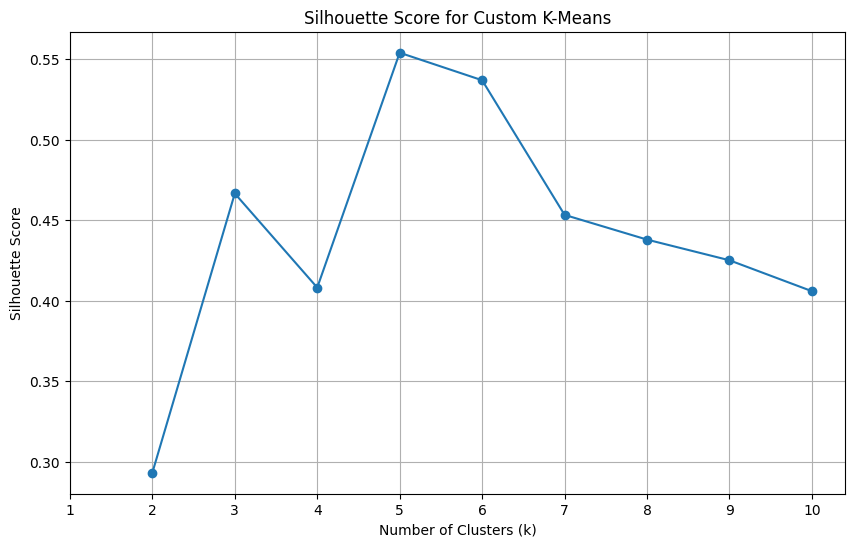

In [17]:
# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Custom K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

Now, let's re-evaluate the optimal `k` considering both the Elbow Method and the Silhouette Score plot. Typically, the `k` with the highest Silhouette Score is considered optimal, provided it also aligns with a reasonable 'elbow' in the inertia plot.

After observing these plots, you can refine your choice for `k_optimal_final` in the subsequent cells if needed. We will then proceed with a summary of these findings.

### Davies-Bouldin Index Calculation

To further evaluate the clustering quality, we will calculate the Davies-Bouldin Index. A lower Davies-Bouldin Index indicates better clustering, where clusters are more compact and further apart from each other.

In [18]:
from sklearn.metrics import davies_bouldin_score

# Davies-Bouldin Index for SCALED data
db_custom_scaled = davies_bouldin_score(X_scaled, assignments_custom_final)
db_sk_scaled = davies_bouldin_score(X_scaled, assignments_sk)

print(f"Davies-Bouldin Index for Custom K-Means (Scaled, k={k_optimal_final}): {db_custom_scaled:.2f}")
print(f"Davies-Bouldin Index for Scikit-learn K-Means (Scaled, k={k_optimal_final}): {db_sk_scaled:.2f}")

# Davies-Bouldin Index for UNSCALED data
db_custom_unscaled = davies_bouldin_score(X, assignments_custom_unscaled)
db_sk_unscaled = davies_bouldin_score(X, assignments_sk_unscaled)

print(f"\nDavies-Bouldin Index for Custom K-Means (Unscaled, k={k_optimal_unscaled_final}): {db_custom_unscaled:.2f}")
print(f"Davies-Bouldin Index for Scikit-learn K-Means (Unscaled, k={k_optimal_unscaled_final}): {db_sk_unscaled:.2f}")

Davies-Bouldin Index for Custom K-Means (Scaled, k=5): 0.57
Davies-Bouldin Index for Scikit-learn K-Means (Scaled, k=5): 0.57

Davies-Bouldin Index for Custom K-Means (Unscaled, k=3): 0.72
Davies-Bouldin Index for Scikit-learn K-Means (Unscaled, k=3): 0.72


### Interpretation of Davies-Bouldin Index

From the Davies-Bouldin Index values, you can observe:

*   **Scaled Data:** The values for both custom and scikit-learn K-Means on scaled data should be relatively low and similar, reaffirming the good clustering structure.
*   **Unscaled Data:** The values for unscaled data are likely to be higher, indicating less optimal clustering compared to the scaled data. This further supports the importance of feature scaling for K-Means.

Based on the Elbow Method plot, let's assume `k=5` or `k=4` is the optimal number of clusters (you can adjust this based on your observation of the plot). We will now run our custom K-Means with the chosen optimal `k` and then compare it with scikit-learn's K-Means.

In [8]:
# Assuming k_optimal is chosen as 5 from the elbow plot
k_optimal_final = 5 # Adjust this based on your elbow plot observation

assignments_custom_final, centroids_custom_final, inertia_custom_final = kmeans(X_scaled, k=k_optimal_final, random_state=42)

print(f"Custom K-Means final Inertia for k={k_optimal_final}: {inertia_custom_final:.2f}")

# Calculate Silhouette Score for custom K-Means
silhouette_custom = silhouette_score(X_scaled, assignments_custom_final)
print(f"Custom K-Means Silhouette Score for k={k_optimal_final}: {silhouette_custom:.2f}")

K-Means converged at iteration 11
Custom K-Means final Inertia for k=5: 65.58
Custom K-Means Silhouette Score for k=5: 0.55


Now, let's use scikit-learn's `KMeans` to perform clustering with the same optimal `k` and compare the results.

In [9]:
# Scikit-learn's K-Means
sk_kmeans = KMeans(n_clusters=k_optimal_final, random_state=42, n_init=10) # n_init for modern scikit-learn
sk_kmeans.fit(X_scaled)

assignments_sk = sk_kmeans.labels_
centroids_sk = sk_kmeans.cluster_centers_
inertia_sk = sk_kmeans.inertia_

print(f"Scikit-learn K-Means Inertia for k={k_optimal_final}: {inertia_sk:.2f}")

# Calculate Silhouette Score for scikit-learn K-Means
silhouette_sk = silhouette_score(X_scaled, assignments_sk)
print(f"Scikit-learn K-Means Silhouette Score for k={k_optimal_final}: {silhouette_sk:.2f}")

Scikit-learn K-Means Inertia for k=5: 65.57
Scikit-learn K-Means Silhouette Score for k=5: 0.55


Let's visualize the clusters from scikit-learn's K-Means for comparison.

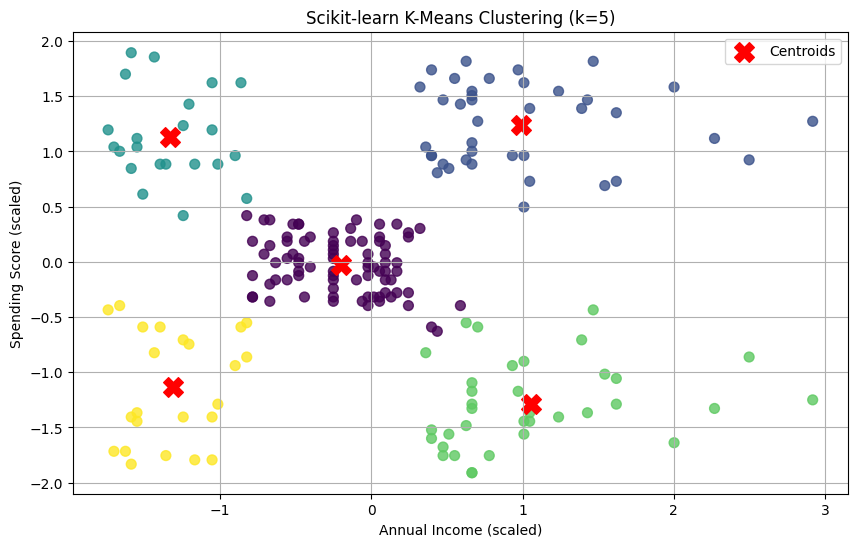

In [10]:
# Visualize scikit-learn K-Means clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=assignments_sk, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids_sk[:, 0], centroids_sk[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'Scikit-learn K-Means Clustering (k={k_optimal_final})')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.grid(True)
plt.show()

### Summary and Comparison

We have successfully implemented K-Means from scratch and compared its performance with scikit-learn's implementation. Here's a brief summary of the results:

*   **Inertia (Within-cluster Sum of Squares):** This metric measures how internally coherent clusters are. Lower values are better. We expect our custom implementation's inertia to be close to scikit-learn's, especially with a good `random_state` for initial centroids.
*   **Silhouette Score:** This metric measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). Values range from -1 to +1, where higher values indicate better-defined clusters.

By comparing the inertia and Silhouette Scores from both implementations, we can validate the correctness and performance of our custom K-Means algorithm.

## Investigating the Influence of Feature Scaling on Clustering

Now, let's explore how feature scaling affects the clustering results. We will run our custom K-Means and the Elbow Method on the **original, unscaled data** (`X`) to see the difference compared to using `X_scaled`.

First, let's determine the optimal number of clusters for the unscaled data using the Elbow Method.

Running Elbow Method on unscaled data...
K-Means converged at iteration 2
K-Means converged at iteration 9
K-Means converged at iteration 16
K-Means converged at iteration 19
K-Means converged at iteration 11
K-Means converged at iteration 5
K-Means converged at iteration 8
K-Means converged at iteration 7
K-Means converged at iteration 8
K-Means converged at iteration 8


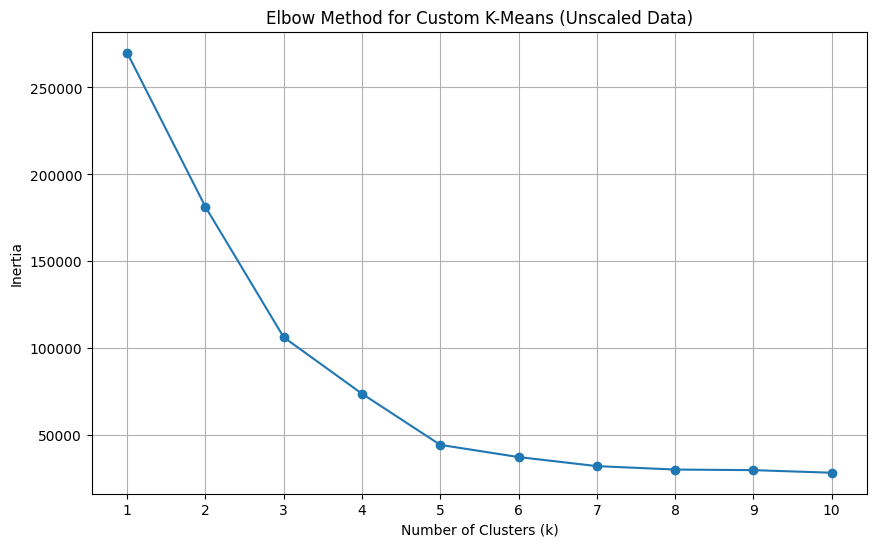

In [11]:
# Elbow Method for custom K-Means on UNSEALED data
inertias_unscaled = []
k_range_unscaled = range(1, 11) # Test k from 1 to 10

print("Running Elbow Method on unscaled data...")
for k in k_range_unscaled:
    _, _, current_inertia_unscaled = kmeans(X, k=k, random_state=42)
    inertias_unscaled.append(current_inertia_unscaled)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range_unscaled, inertias_unscaled, marker='o')
plt.title('Elbow Method for Custom K-Means (Unscaled Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range_unscaled))
plt.grid(True)
plt.show()

Observe the Elbow Method plot for the unscaled data. You might notice a different 'elbow' or a less clear elbow compared to the scaled data. Let's assume an optimal `k` (e.g., `k=3` or `k=4`) based on this plot for further comparison.

In [12]:
# Assuming k_optimal_unscaled is chosen as 3 from the elbow plot for unscaled data
k_optimal_unscaled_final = 3 # Adjust this based on your elbow plot observation for unscaled data

print(f"Running custom K-Means on unscaled data with k={k_optimal_unscaled_final}...")
assignments_custom_unscaled, centroids_custom_unscaled, inertia_custom_unscaled = kmeans(X, k=k_optimal_unscaled_final, random_state=42)

print(f"Custom K-Means final Inertia for unscaled data (k={k_optimal_unscaled_final}): {inertia_custom_unscaled:.2f}")

# Calculate Silhouette Score for custom K-Means on unscaled data
silhouette_custom_unscaled = silhouette_score(X, assignments_custom_unscaled)
print(f"Custom K-Means Silhouette Score for unscaled data (k={k_optimal_unscaled_final}): {silhouette_custom_unscaled:.2f}")

Running custom K-Means on unscaled data with k=3...
K-Means converged at iteration 16
Custom K-Means final Inertia for unscaled data (k=3): 106348.37
Custom K-Means Silhouette Score for unscaled data (k=3): 0.47


Now, let's visualize the clusters formed by our custom K-Means implementation on the **unscaled data**.

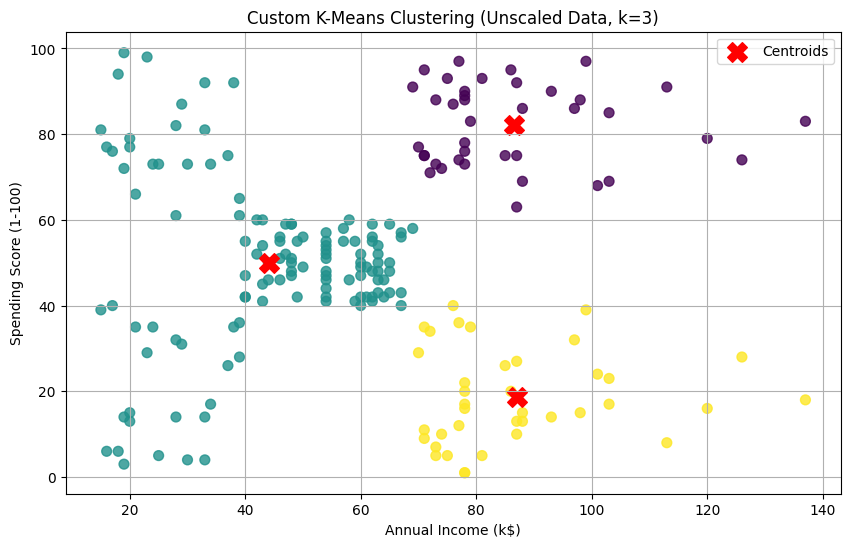

In [13]:
# Visualize the custom K-Means clusters (UNSCALED data)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=assignments_custom_unscaled, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids_custom_unscaled[:, 0], centroids_custom_unscaled[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'Custom K-Means Clustering (Unscaled Data, k={k_optimal_unscaled_final})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

Next, let's run scikit-learn's K-Means on the **unscaled data** for comparison.

In [14]:
# Scikit-learn's K-Means on UNSCALED data
sk_kmeans_unscaled = KMeans(n_clusters=k_optimal_unscaled_final, random_state=42, n_init=10)
sk_kmeans_unscaled.fit(X)

assignments_sk_unscaled = sk_kmeans_unscaled.labels_
centroids_sk_unscaled = sk_kmeans_unscaled.cluster_centers_
inertia_sk_unscaled = sk_kmeans_unscaled.inertia_

print(f"Scikit-learn K-Means Inertia for unscaled data (k={k_optimal_unscaled_final}): {inertia_sk_unscaled:.2f}")

# Calculate Silhouette Score for scikit-learn K-Means on unscaled data
silhouette_sk_unscaled = silhouette_score(X, assignments_sk_unscaled)
print(f"Scikit-learn K-Means Silhouette Score for unscaled data (k={k_optimal_unscaled_final}): {silhouette_sk_unscaled:.2f}")

Scikit-learn K-Means Inertia for unscaled data (k=3): 106348.37
Scikit-learn K-Means Silhouette Score for unscaled data (k=3): 0.47


Finally, let's visualize the clusters from scikit-learn's K-Means on the **unscaled data**.

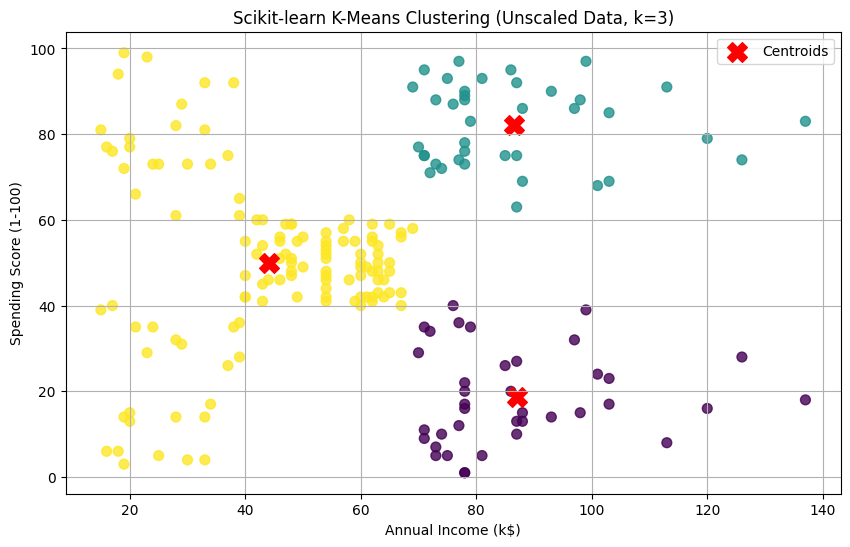

In [15]:
# Visualize scikit-learn K-Means clusters (UNSCALED data)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=assignments_sk_unscaled, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids_sk_unscaled[:, 0], centroids_sk_unscaled[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'Scikit-learn K-Means Clustering (Unscaled Data, k={k_optimal_unscaled_final})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Comparison of Scaled vs. Unscaled Data

After executing the cells above, we can now compare the clustering results obtained with and without feature scaling. Consider the following points:

*   **Elbow Method:** How did the elbow curve differ? Was it clearer or less pronounced with unscaled data?
*   **Inertia:** You'll likely observe a significantly larger inertia value for unscaled data. This is because unscaled features can have vastly different ranges, leading to larger squared distances.
*   **Silhouette Score:** Compare the Silhouette scores. Feature scaling often leads to better-defined and more compact clusters, which should be reflected in a higher Silhouette score for scaled data.
*   **Visualizations:** Visually compare the cluster shapes and centroid positions. Unscaled data often results in clusters dominated by features with larger ranges, potentially distorting the true underlying structure.

This comparison demonstrates the critical importance of feature scaling, especially standardization, in algorithms like K-Means that rely on distance calculations. Scaling ensures that all features contribute equally to the distance metric, leading to more meaningful and accurate clustering.